# Adaptive blue noise sampling

Interactive CPU-friendly notebook for comparing a uniform Gaussian blue noise baseline against an adaptive radial foveation run.

In [15]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # For Windows

import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.10.0+cu128
True


## Imports and parameters

In [16]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

candidate_dir = Path.cwd()
if (candidate_dir / "gaussian_blue_noise_gpu.py").exists():
    python_dir = candidate_dir
elif (candidate_dir / "python" / "gaussian_blue_noise_gpu.py").exists():
    python_dir = candidate_dir / "python"
else:
    python_dir = Path("python").resolve()

if str(python_dir) not in sys.path:
    sys.path.insert(0, str(python_dir))

from gaussian_blue_noise_gpu import optimize_adaptive_blue_noise, optimize_uniform_blue_noise
from spectra import compute_1d_power_spectrum, compute_2d_power_spectrum

n_points = 2048
n_iterations = 2000
gbn_step_size = 1e-3
device = "cuda"
seed = 1234

density_resolution = 256
neg_res = 128
num_bins = 80
max_freq = 5.0
psd_grid_size = 96

plt.rcParams["figure.dpi"] = 120


def draw_periodogram(ax, power_2d, extent, title):
    display_power = np.array(power_2d, dtype=np.float64, copy=True)
    center_y = display_power.shape[0] // 2
    center_x = display_power.shape[1] // 2
    display_power[center_y, center_x] = np.nan
    log_power = np.log1p(display_power)
    vmin, vmax = np.nanpercentile(log_power, [2.0, 99.0])
    image = ax.imshow(
        log_power,
        origin="lower",
        extent=extent,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )
    ax.set_title(title)
    ax.set_xlabel("kx / sqrt(N)")
    ax.set_ylabel("ky / sqrt(N)")
    return image


## Uniform GBN baseline

In [17]:
uniform_result = optimize_uniform_blue_noise(
    n_points=n_points,
    n_dims=2,
    n_iterations=n_iterations,
    step_size=gbn_step_size,
    seed=seed,
    device=device,
    log_every=1000,
    verbose=True,
)
uniform_points = uniform_result["points"]
uniform_points.shape

[GBN] device=cuda, N=2048, d=2, sigma_base=1.0, iters=2000
[GBN] sigma=0.022097  n_periods=1  effective_step=0.000022
  iter       1  energy=3.169678e+00
  iter    1000  energy=2.641651e+00


KeyboardInterrupt: 

## Uniform point visualisation

Run and inspect the uniform GBN point set before moving on to the adaptive experiment.


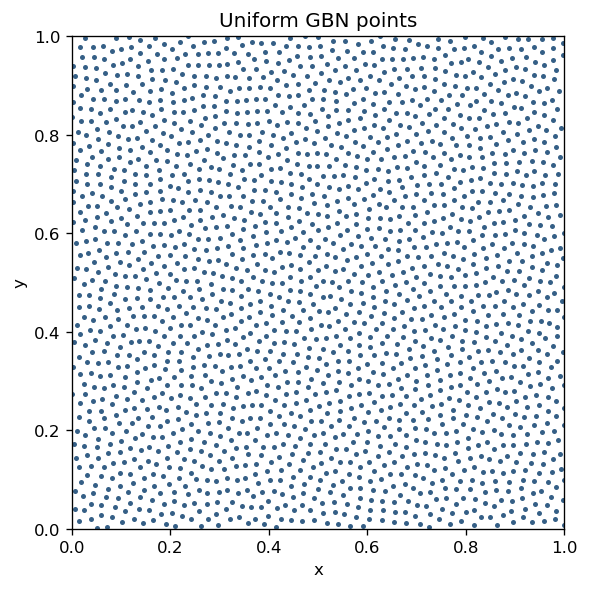

In [ ]:
def draw_points(ax, points, title, background=None):
    if background is not None:
        ax.imshow(background, origin="lower", extent=(0, 1, 0, 1), cmap="viridis", alpha=0.9)
        point_colour = "white"
    else:
        point_colour = "#1f4e79"
    ax.scatter(points[:, 0], points[:, 1], s=9, color=point_colour, alpha=0.9, linewidths=0)
    ax.set_title(title)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")


fig, ax = plt.subplots(figsize=(5.0, 4.8), constrained_layout=True)
draw_points(ax, uniform_points, "Uniform GBN points")
plt.show()


## Uniform corrected radial PSD and 2D periodogram

Start with the stationary uniform case. These spectra use the point-process Fourier estimators from `spectra.py`, with power normalised by point count.


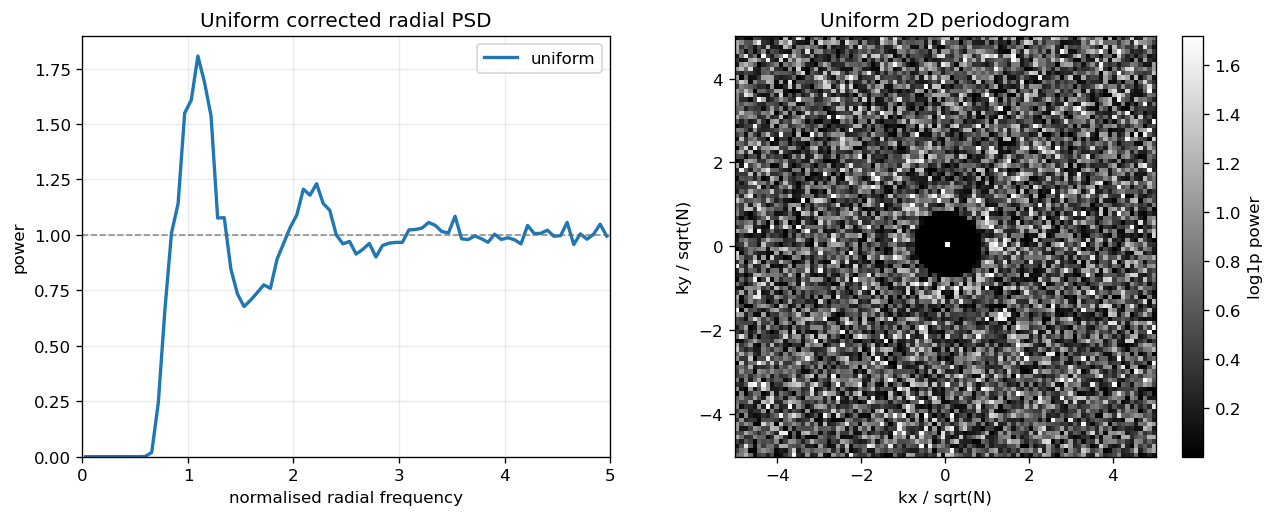

In [ ]:
def compute_corrected_psd(points):
    freqs, radial_power = compute_1d_power_spectrum(
        points,
        domain_size=1.0,
        num_bins=num_bins,
        max_freq=max_freq,
    )
    power_2d, extent = compute_2d_power_spectrum(
        points,
        domain_size=1.0,
        grid_size=psd_grid_size,
        max_freq=max_freq,
    )
    return freqs, radial_power, power_2d, extent


uniform_freqs, uniform_radial_power, uniform_power_2d, uniform_extent = compute_corrected_psd(uniform_points)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), constrained_layout=True)
axes[0].plot(uniform_freqs, uniform_radial_power, label="uniform", linewidth=2.0)
axes[0].axhline(1.0, color="#666666", linestyle="--", linewidth=1.0, alpha=0.7)
axes[0].set_title("Uniform corrected radial PSD")
axes[0].set_xlabel("normalised radial frequency")
axes[0].set_ylabel("power")
axes[0].set_xlim(0.0, max_freq)
axes[0].set_ylim(bottom=0.0)
axes[0].grid(True, alpha=0.25)
axes[0].legend()
image = draw_periodogram(axes[1], uniform_power_2d, uniform_extent, "Uniform 2D periodogram")
fig.colorbar(image, ax=axes[1], label="log1p power")
plt.show()


## Controlled radial foveation density

The density is radial, centred in the unit square, and normalised to mean one so the point count remains easy to compare with the uniform baseline.

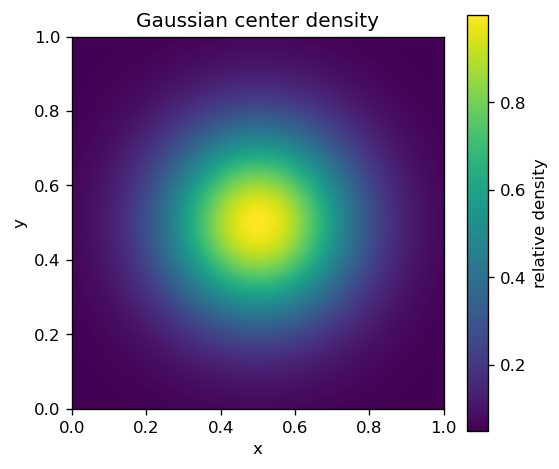

In [ ]:
def density_gaussian_center(
    width: int,
    height: int,
    sigma: float = 0.18,      # in normalized units of the image (0..~0.707 max radius)
    peak: float = 1.0,        # density at center
    floor: float = 0.05,      # minimum density in the periphery
    center: tuple[float,float] = (0.5, 0.5),
) -> np.ndarray:
    """
    Radial gaussian density: floor + (peak-floor)*exp(-r^2/(2*sigma^2))
    """
    y = (np.arange(height) + 0.5) / height
    x = (np.arange(width) + 0.5) / width
    xx, yy = np.meshgrid(x, y, indexing="xy")

    cx, cy = center
    dx = xx - cx
    dy = yy - cy
    r2 = dx * dx + dy * dy

    d = floor + (peak - floor) * np.exp(-0.5 * r2 / (sigma*sigma))
    return d.astype(np.float32)


density = density_gaussian_center(density_resolution, density_resolution)
density_t = torch.from_numpy(density)
density_map = density_t

fig, ax = plt.subplots(figsize=(5.0, 4.5))
image = ax.imshow(density, origin="lower", extent=(0, 1, 0, 1), cmap="viridis")
ax.set_title("Gaussian center density")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(image, ax=ax, label="relative density")
plt.show()

## Adaptive GBN run

Adaptive Gaussian Blue Noise: device=cuda, N=2048, iters=2000, sigma_base=0.25, periodic=False, neg_res=128


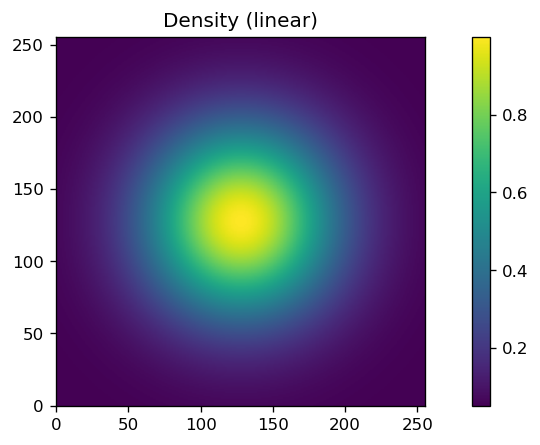

iter       1  energy=7.293829e-02
iter    1000  energy=-3.016888e-01
iter    2000  energy=-3.004944e-01


(2048, 2)

In [ ]:
adaptive_result = optimize_adaptive_blue_noise(
    density_map=density_t,
    n_points=2048,
    base_sigma=0.25,
    n_iterations=n_iterations,
    seed=0,
    periodic=False,
    neg_res=128,
    attract_strength=0.5,
    shape_updates_per_iter=1,
    shape_damping=0.5,
)
adaptive_points = adaptive_result["points"]
adaptive_points.shape

## Point/density visualisation

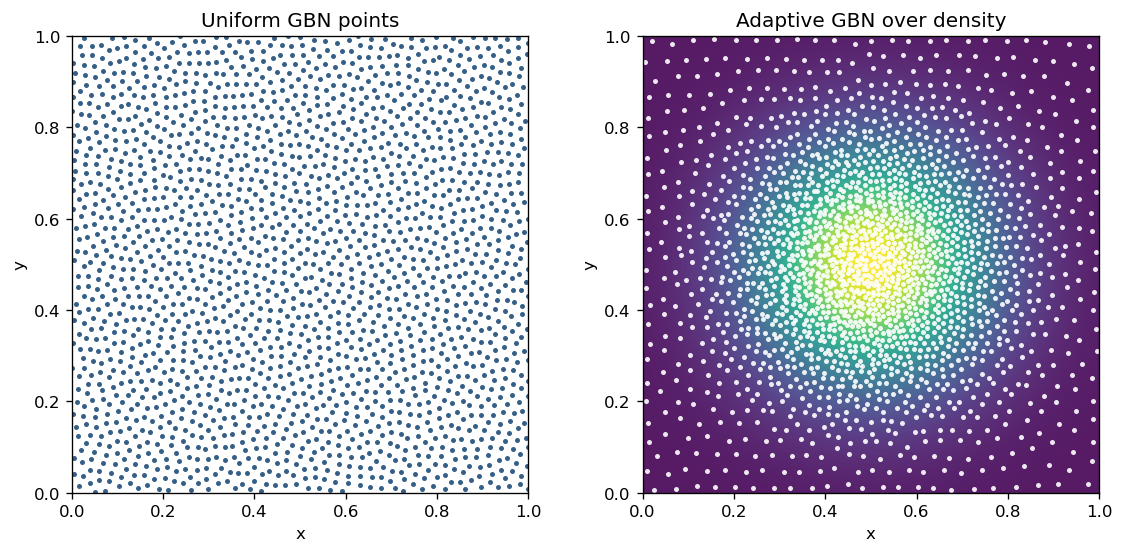

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.5), constrained_layout=True)
draw_points(axes[0], uniform_points, "Uniform GBN points")
draw_points(axes[1], adaptive_points, "Adaptive GBN over density", background=density)
plt.show()


## Adaptive global PSD and periodogram

Now inspect the adaptive result. The global adaptive periodogram is useful, but it mixes the intentional foveated density gradient with sampling-error structure.


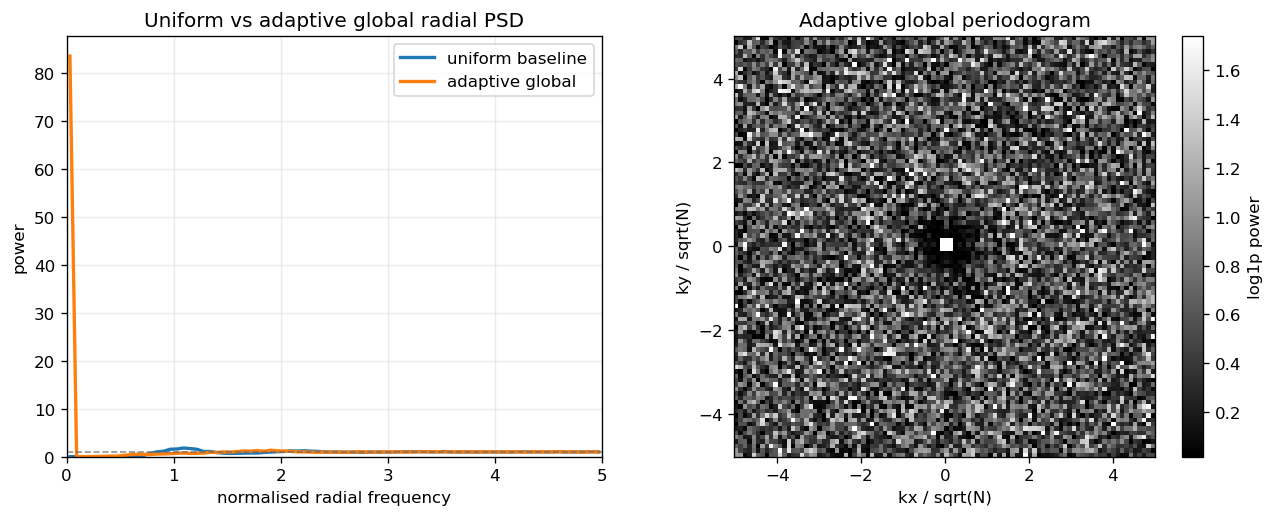

In [ ]:
adaptive_freqs, adaptive_radial_power, adaptive_power_2d, adaptive_extent = compute_corrected_psd(adaptive_points)
raw_global_power_2d = adaptive_power_2d
raw_global_extent = adaptive_extent

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), constrained_layout=True)
axes[0].plot(uniform_freqs, uniform_radial_power, label="uniform baseline", linewidth=2.0)
axes[0].plot(adaptive_freqs, adaptive_radial_power, label="adaptive global", linewidth=2.0)
axes[0].axhline(1.0, color="#666666", linestyle="--", linewidth=1.0, alpha=0.7)
axes[0].set_title("Uniform vs adaptive global radial PSD")
axes[0].set_xlabel("normalised radial frequency")
axes[0].set_ylabel("power")
axes[0].set_xlim(0.0, max_freq)
axes[0].set_ylim(bottom=0.0)
axes[0].grid(True, alpha=0.25)
axes[0].legend()
image = draw_periodogram(axes[1], raw_global_power_2d, raw_global_extent, "Adaptive global periodogram")
fig.colorbar(image, ax=axes[1], label="log1p power")
plt.show()


## Local/windowed adaptive PSD

Local windows rescale selected radial bands back to a unit domain before estimating spectra. This makes the foveal and peripheral bands easier to compare.

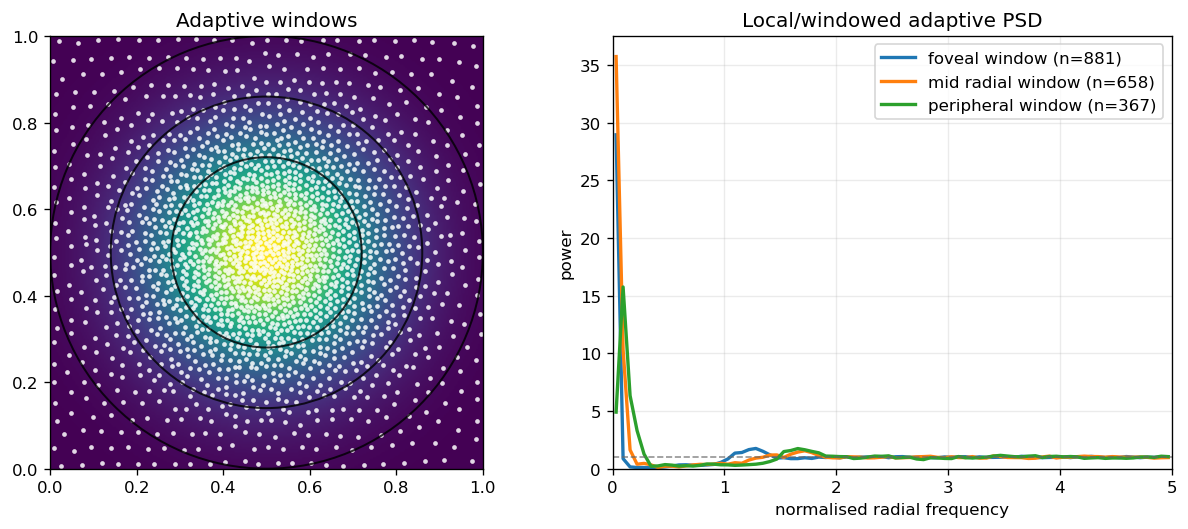

In [ ]:
def radial_window_points(points, radius_min, radius_max):
    center = np.array([0.5, 0.5], dtype=np.float64)
    offset = points[:, :2] - center[None, :]
    radius = np.linalg.norm(offset, axis=1)
    selected = points[(radius >= radius_min) & (radius <= radius_max), :2]
    if selected.shape[0] == 0:
        return selected
    half_width = max(radius_max, 1e-6)
    normalised = (selected - (center[None, :] - half_width)) / (2.0 * half_width)
    return np.clip(normalised, 0.0, 1.0)


local_windows = {
    "foveal window": (0.00, 0.22),
    "mid radial window": (0.22, 0.36),
    "peripheral window": (0.36, 0.50),
}

fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.3), constrained_layout=True)
axes[0].imshow(density, origin="lower", extent=(0, 1, 0, 1), cmap="viridis")
axes[0].scatter(adaptive_points[:, 0], adaptive_points[:, 1], s=8, color="white", alpha=0.85, linewidths=0)
axes[0].set_title("Adaptive windows")
axes[0].set_xlim(0.0, 1.0)
axes[0].set_ylim(0.0, 1.0)
axes[0].set_aspect("equal", adjustable="box")
for label, (_, radius_max) in local_windows.items():
    circle = plt.Circle((0.5, 0.5), radius_max, fill=False, linewidth=1.2, alpha=0.8)
    axes[0].add_patch(circle)

for label, (radius_min, radius_max) in local_windows.items():
    window_points = radial_window_points(adaptive_points, radius_min, radius_max)
    if window_points.shape[0] < 4:
        freqs = np.linspace(0.0, max_freq, num_bins)
        power = np.zeros_like(freqs)
    else:
        freqs, power = compute_1d_power_spectrum(
            window_points,
            domain_size=1.0,
            num_bins=num_bins,
            max_freq=max_freq,
        )
    axes[1].plot(freqs, power, linewidth=2.0, label=f"{label} (n={window_points.shape[0]})")

axes[1].axhline(1.0, color="#666666", linestyle="--", linewidth=1.0, alpha=0.7)
axes[1].set_title("Local/windowed adaptive PSD")
axes[1].set_xlabel("normalised radial frequency")
axes[1].set_ylabel("power")
axes[1].set_xlim(0.0, max_freq)
axes[1].set_ylim(bottom=0.0)
axes[1].grid(True, alpha=0.25)
axes[1].legend()
plt.show()

## Short interpretation notes

**Uniform first.** The uniform baseline is the cleanest comparison to the paper's stationary GBN spectra. The low-frequency notch should be easier to see than in lightweight smoke tests, though it is still much shorter than the paper's 1M-iteration Figure 1 run.

**Adaptive second.** The adaptive global curve can look less clean because it mixes true sample repulsion with the imposed foveated density gradient. Use the local/windowed PSD to compare foveal and peripheral behaviour after reducing that non-stationary density effect.
